# **Projeto de Limpeza de Dados**

Este projeto tem como objetivo tratar e organizar um banco de dados com informações de vendas de uma cafeteria.  
Durante o processo, serão realizadas etapas de limpeza dos dados, padronização de valores e análise para melhorar a qualidade das informações.

O projeto utilizará `Pandas` · `Gráficos`

### **Primeira Etapa: Importações**
Primeiro começamos com as importações de todas as biblitotecas que serão usadas. Esse processo foi feito em uma única célula.

In [28]:
import pandas as pd #Biblioteca Pandas, apelidado de pd

#Bibliotecas para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Operações matemáticas
import numpy as np

#Conferir as importações
print('Importações completas')

Importações completas


### **Segunda Etapa: Trazer o arquivo `csv` e ler com o pandas**

In [2]:
arquivo= 'dirty_cafe_sales.csv' #Optei por colocar o arquivo em uma variável
tabela= pd.read_csv(arquivo, 
                    sep= ',', #Método de separação do arquivo CSV
                    encoding='UTF-8', #Codificação
                    decimal='.', #Pontuação utilizada para números Float
                    )

#Tabela.sample para mostrar linhas aleatórias da minha tabela (escolhi 15)
tabela.sample(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4464,TXN_7970906,Coffee,UNKNOWN,2.0,8.0,ERROR,In-store,2023-03-07
9431,TXN_9817135,Salad,1,5.0,5.0,Digital Wallet,ERROR,2023-03-25
8783,TXN_6567287,Cookie,4,1.0,4.0,Digital Wallet,Takeaway,NaN
860,TXN_3197752,Smoothie,2,4.0,8.0,NaN,NaN,2023-03-10
8723,TXN_7248722,Cake,3,3.0,9.0,Cash,Takeaway,2023-04-06
645,TXN_8255965,Juice,NaN,3.0,6.0,NaN,In-store,2023-11-16
272,TXN_1746320,Salad,1,5.0,5.0,Cash,NaN,2023-11-14
7632,TXN_9430262,Coffee,5,2.0,10.0,NaN,NaN,2023-03-16
5484,TXN_7704229,Coffee,UNKNOWN,2.0,8.0,Cash,NaN,2023-07-15
7012,TXN_8859035,Cake,3,3.0,9.0,Digital Wallet,Takeaway,2023-01-19


### **Terceira Etapa: Limpeza e organização da tabela**

Vão ser modificados:
* Nome das colunas
    - Retirada de espaços
    - Letras minúsculas 
* Índice das colunas
* Valores faltando
    - `ERROR`
    - `UNKNOWN`
* Tipos errado de dados


#### **Nome das colunas:**
 Retirada de espaços

In [4]:
#Também poderia ter sido feito dessa forma
tabela.columns= tabela.columns.str.replace(" ",'_')
tabela

,transaction_id,Item,Quantity,price_per_unit,total_spent,payment_method,Location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


Letras maiúsculas e espaços

In [5]:
#Deixei tudo em minúsculo e retirei espaços antes e depois de cada nome
tabela.columns = tabela.columns.str.lower().str.strip()
display(tabela)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


#### **Índice das colunas**

In [ ]:
#Aqui eu estabeleci a coluna "transaction_id" como meu índice, já que é a melhor forma de identificação

#Há duas formas de se fazer:
tabela= tabela.set_index('transaction_id') #Fazendo uma reatribuição 

display(tabela)

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


#### **Valores faltando**

In [7]:
#Aqui eu transformo todos os valores faltando por Nan (Not a number)
tabela= tabela.replace(['ERROR','UNKNOWN'], np.nan)
display(tabela)

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


#### **Tipos errados de dados**

In [8]:
#Ver os tipos de dados atuais
tabela.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, TXN_1961373 to TXN_6170729
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item              9031 non-null   str  
 1   quantity          9521 non-null   str  
 2   price_per_unit    9467 non-null   str  
 3   total_spent       9498 non-null   str  
 4   payment_method    6822 non-null   str  
 5   location          6039 non-null   str  
 6   transaction_date  9540 non-null   str  
dtypes: str(7)
memory usage: 625.0+ KB


Vejo que há colunas de número (tanto `Inteiro` como `Float`) e datas que estão como `Strings`

In [30]:
#Inteiros
tabela['quantity'] = tabela.quantity.astype('Int64') #Detlhe para I maiúsculo, que engloba valores faltosos

In [10]:
#Pontos flutuantes
tabela['price_per_unit']= tabela.price_per_unit.astype('Float64') #Mesma coisa para o F maiúsculo 
tabela['total_spent']= tabela.total_spent.astype('Float64')

In [ ]:
#Datas
tabela['transaction_date']= pd.to_datetime(tabela['transaction_date']) #pd.to_datetime e sintaxe diferente

In [12]:
#Variáveis categóricas
#São opcionais mas ajudam na identificação dos tipos de dados
tabela['location']= tabela.location.astype('category')
tabela['item']= tabela.item.astype('category')
tabela['payment_method']= tabela.payment_method.astype('category')

In [13]:
#Para conferir, eu finalizo com tabela.info novamente
tabela.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, TXN_1961373 to TXN_6170729
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   item              9031 non-null   category      
 1   quantity          9521 non-null   Int64         
 2   price_per_unit    9467 non-null   Float64       
 3   total_spent       9498 non-null   Float64       
 4   payment_method    6822 non-null   category      
 5   location          6039 non-null   category      
 6   transaction_date  9540 non-null   datetime64[us]
dtypes: Float64(2), Int64(1), category(3), datetime64[us](1)
memory usage: 449.3+ KB


### **Quarta Etapa: Gráficos**

Nesta etapa, iremos usar a tabela, agora limpa, para montar alguns gráficos que apresentem informações úteis.
Serão usados:
* `Gráfico de Linhas`
* `Gráfico de Barras` 

Criamos a variável `exemplo1` para guardar a base de dados que vai ser utilizada no primeiro gráfico.
Agrupamos com a função `groupby` todos os meses e a soma da quantidade de produtos vendidos em cada mês.

In [ ]:
exemplo1= tabela.groupby(tabela['transaction_date'].dt.to_period('M')).quantity.sum()

#Criamos uma series

<Axes: title={'center': 'Distribuição de vendas por tempo'}, xlabel='Data', ylabel='Vendas'>

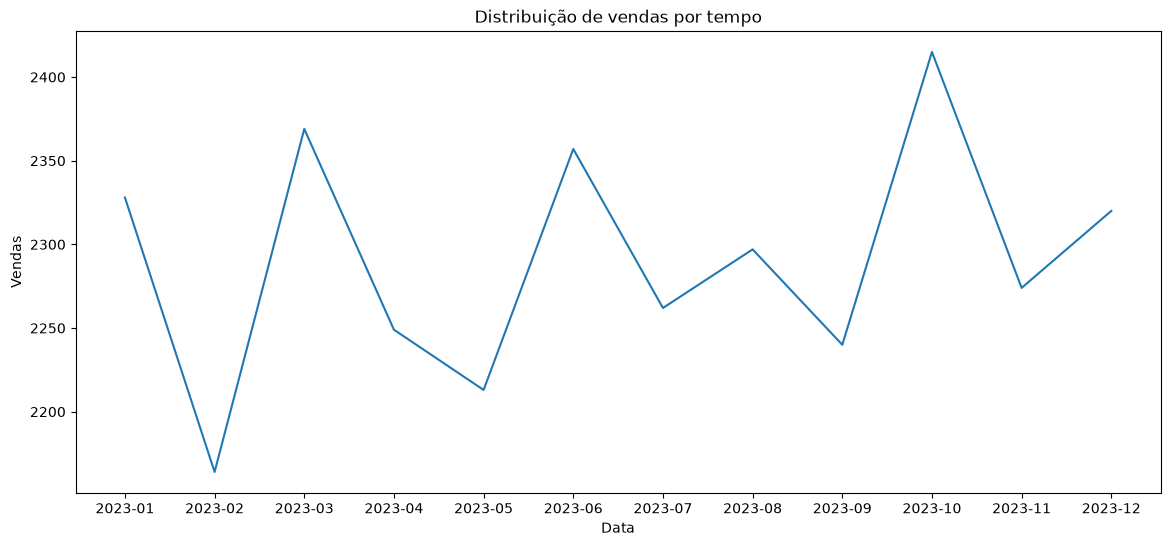

In [32]:
#Definimos o tamanho do gráfico
plt.figure(figsize=(14,6)) 

#Definimos o título e o nome dos eixos
plt.title('Distribuição de vendas por tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')

#Agora montamos o gráfico
sns.lineplot(x=exemplo1.index.astype(str), #Atenção para o astype(str)
             y=exemplo1.values)

Criamos a variável `exemplo2` para guardar a base de dados usado no segundo e último gráfico.
Agrupamos novamente com `groupby` para unir todos os itens vendidos e a soma de suas quantidades, respectivamente.

In [16]:
exemplo2= tabela.groupby(['item']).quantity.sum() #Poderíamos ordernar os valores

#Criamos uma Series

<Axes: title={'center': 'Quantidade de vendas por produto'}, xlabel='Produtos', ylabel='Quantidade'>

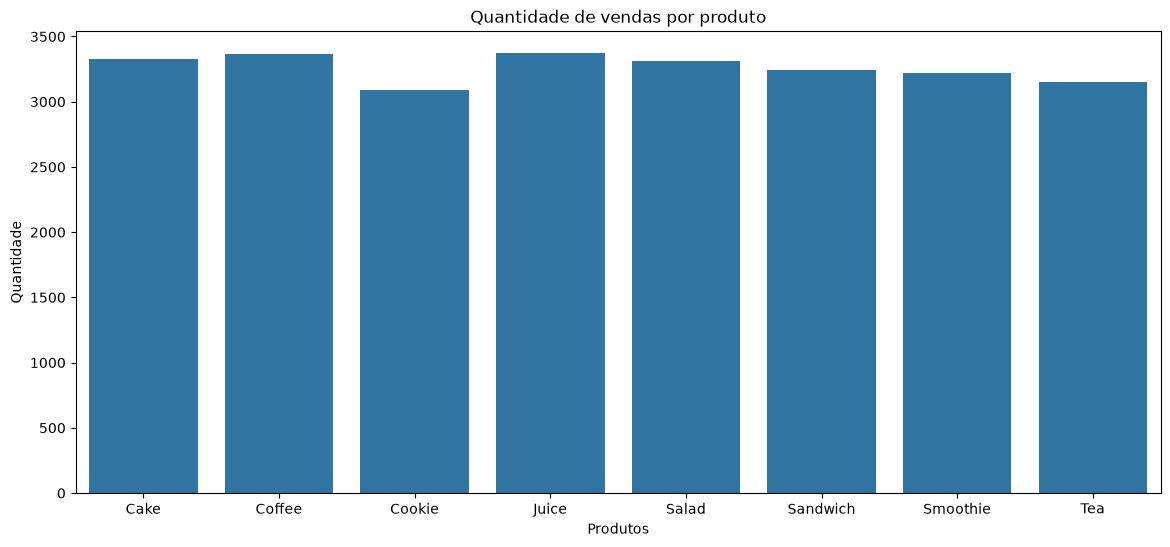

In [17]:
#Tamanho do gráfico
plt.figure(figsize=(14,6))

#Título e nome dos eixos
plt.title('Quantidade de vendas por produto')
plt.ylabel('Quantidade')
plt.xlabel('Produtos')

#Criamos o gráfico
sns.barplot(x=exemplo2.index,
            y=exemplo2.values 
            )

### **Outras funções importantes**

Também há funções como o `loc` ou `iloc` para recortar trechos específicos do gráfico.

In [18]:
tabela

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,<NA>,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
TXN_9659401,NaN,3,<NA>,3.0,Digital Wallet,NaN,2023-06-02
TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


In [46]:
#O iloc é posicional, portanto não depende do nome das colunas ou de linhas específicas
tabela.iloc[2:5,-2:]

,location,transaction_date
transaction_id,,
TXN_4271903,In-store,2023-07-19
TXN_7034554,NaN,2023-04-27
TXN_3160411,In-store,2023-06-11


In [43]:
#O loc não é posicional, portanto necessita dos nomes específicos
#Sempre vem primeiro a linha e depois a coluna
tabela.loc['TXN_1961373', ['item', 'quantity']] #Posso passar uma lista de linhas ou uma lista de colunas


item        Coffee
quantity         2
Name: TXN_1961373, dtype: object

#### **Argumentos importantes do `Loc`**

* `&`

In [ ]:
tabela.loc[(tabela['item']== 'Coffee') & (tabela['quantity']>=4)] #Pegará linhas em que as duas condições são verdadeiras

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_6688524,Coffee,4,2.0,8.0,NaN,NaN,2023-06-29
TXN_3085509,Coffee,4,2.0,8.0,Digital Wallet,In-store,2023-04-15
TXN_8779771,Coffee,4,2.0,8.0,Cash,In-store,2023-07-25
TXN_3092382,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-02-21
TXN_6258471,Coffee,5,2.0,10.0,Digital Wallet,In-store,2023-09-23
...,...,...,...,...,...,...,...
TXN_6587628,Coffee,5,2.0,10.0,NaN,In-store,2023-05-09
TXN_6411708,Coffee,4,2.0,8.0,Credit Card,In-store,2023-05-20
TXN_1191659,Coffee,4,2.0,<NA>,Credit Card,In-store,2023-11-21


* `|`

In [44]:
tabela.loc[(tabela['total_spent']>=10) | (tabela['payment_method']=='Credit Card')] #Pegará linhas em que uma ou outra condição é verdadeira

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Credit Card,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,<NA>,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
...,...,...,...,...,...,...,...
TXN_1538510,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-05-22
TXN_3897619,Sandwich,3,4.0,12.0,Credit Card,Takeaway,2023-02-24
TXN_2739140,Smoothie,4,4.0,16.0,Credit Card,In-store,2023-07-05


* `Between`

In [23]:
tabela.loc[tabela['total_spent'].between(6,12)] #Usa o between como ferramente para dados ordenados

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,NaT
TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...
TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
TXN_1538510,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-05-22
TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24


* `isin`

In [24]:
tabela.loc[tabela['item'].isin(['Coffee', 'Sandwich'])] #O isin é usado para definir um conjunto onde a condição será verdadeira

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31
TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,NaT
...,...,...,...,...,...,...,...
TXN_1538510,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-05-22
TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24
TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30


* `Alteração em uma coluna`

In [45]:
tabela.loc[tabela['total_spent']>10, 'payment_method']= 'Credit Card' #Esse método é utilizado para fazer mudanças em uma coluna usando a condição de outra
tabela

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4,3.0,12.0,Credit Card,In-store,2023-05-16
TXN_4271903,Cookie,4,1.0,<NA>,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
TXN_9659401,NaN,3,<NA>,3.0,Digital Wallet,NaN,2023-06-02
TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


### **Última Etapa: Exportação da tabela limpa**

In [26]:
tabela.to_csv('tabela_limpa.csv',
                encoding='UTF-8',
                sep=',',
                decimal='.',
                )

In [27]:
final= pd.read_csv('tabela_limpa.csv', index_col='transaction_id')
final

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
transaction_id,,,,,,,
TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
TXN_4977031,Cake,4.0,3.0,12.0,Credit Card,In-store,2023-05-16
TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
